The goal is to obtain samples from the boltzmann distribution: example a double well potential with a fast and slow variable. (2 dim)

In [328]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from tqdm import tqdm

COSTRINCTING THE FLOW:
3 coupling affine flow where s and t are mlp, for a total of 6 mlp to train.

In [329]:
def init_mlp_params(key, in_dim, hidden_dim, out_dim):
    k1, k2, k3 = jax.random.split(key, 3)
    return {
        "W1": jax.random.normal(k1, (in_dim, hidden_dim)) * 0.1,
        "b1": jnp.zeros((hidden_dim,)),
        "W2": jax.random.normal(k2, (hidden_dim, hidden_dim)) * 0.1,
        "b2": jnp.zeros((hidden_dim,)),
        "W3": jax.random.normal(k3, (hidden_dim, out_dim)) * 0.1,
        "b3": jnp.zeros((out_dim,))
    }

# Initialize MLP parameters with small random values: weights from a normal distribution and biases as zeros.

#The mlp function defines a simple feedforward neural network with one hidden layer. 
# It takes input x, applies a linear transformation followed by a tanh activation to get the hidden representation h, 
# and then applies another linear transformation to produce the output.
def mlp(params, x):
    h = jnp.tanh(x @ params["W1"] + params["b1"])
    h = jnp.tanh(h @ params["W2"] + params["b2"])
    return h @ params["W3"] + params["b3"]

In [330]:
def init_params(key):
    keys = jax.random.split(key, 20)
    return {
        "s1": init_mlp_params(keys[0], 1, 16, 1),
        "t1": init_mlp_params(keys[1], 1, 16, 1),
        "s2": init_mlp_params(keys[2], 1, 16, 1),
        "t2": init_mlp_params(keys[3], 1, 16, 1),
        "s3": init_mlp_params(keys[4], 1, 16, 1),
        "t3": init_mlp_params(keys[5], 1, 16, 1),
        "s4": init_mlp_params(keys[6], 1, 16, 1),
        "t4": init_mlp_params(keys[7], 1, 16, 1),
        "s5": init_mlp_params(keys[8], 1, 16, 1),
        "t5": init_mlp_params(keys[9], 1, 16, 1),
        "s6": init_mlp_params(keys[10], 1, 16, 1),
        "t6": init_mlp_params(keys[11], 1, 16, 1),
        "s7": init_mlp_params(keys[12], 1, 16, 1),
        "t7": init_mlp_params(keys[13], 1, 16, 1),
        "s8": init_mlp_params(keys[14], 1, 16, 1),
        "t8": init_mlp_params(keys[15], 1, 16, 1),
        "s9": init_mlp_params(keys[16], 1, 16, 1),
        "t9": init_mlp_params(keys[17], 1, 16, 1),
        "s10": init_mlp_params(keys[18], 1, 16, 1),
        "t10": init_mlp_params(keys[19], 1, 16, 1)
    }
# The init_params function initializes the parameters for two coupling layers, each with its own scale (s) and translation (t) MLPs.

def permute(x):
    return x[:, ::-1]

def coupling1(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]
    
    s = mlp(params["s1"], z1)

    t = mlp(params["t1"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling2(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = mlp(params["s2"], z1)

    t = mlp(params["t2"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**2 # Use a quadratic function for translation to increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling3(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s3"], z1)) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t3"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**2 # Use a quadratic function for translation to increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling4(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s4"], z1)**2) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t4"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**3 # Use a cubic function for translation to further increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling5(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s5"], z1)) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t5"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**3 # Use a cubic function for translation to further increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling6(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.sin(mlp(params["s6"], z1)) # Use a sinusoidal function for scale to introduce periodicity

    t = mlp(params["t6"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t 

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling7(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.sin(mlp(params["s7"], z1)) # Use a sinusoidal function for scale to introduce periodicity

    t = mlp(params["t7"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t 

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling8(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s8"], z1)) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t8"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**3 # Use a cubic function for translation to further increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling9(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s9"], z1)) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t9"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**3 # Use a cubic function for translation to further increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling10(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = jnp.tanh(mlp(params["s10"], z1)) # Use a tanh function for scale to introduce nonlinearity and ensure stability

    t = mlp(params["t10"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t**3 # Use a cubic function for translation to further increase nonlinearity

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det


FORWARD FLOW

In [331]:
def forward(params, z):
    x, log_det1 = coupling1(params, z)
    
    x = permute(x)
    
    x, log_det2 = coupling2(params, x)
    
    log_det = log_det1 + log_det2

    x = permute(x) 

    x, log_det3 = coupling3(params, x)

    log_det += log_det3

    x = permute(x)

    x, log_det4 = coupling4(params, x)

    log_det += log_det4

    x = permute(x)

    x, log_det5 = coupling5(params, x)

    log_det += log_det5

    x = permute(x)

    x, log_det6 = coupling6(params, x)

    log_det += log_det6

    x = permute(x)

    x, log_det7 = coupling7(params, x)

    log_det += log_det7

    x = permute(x)

    x, log_det8 = coupling8(params, x)

    log_det += log_det8

    x = permute(x)

    x, log_det9 = coupling9(params, x)

    log_det += log_det9

    x = permute(x)

    x, log_det10 = coupling10(params, x)

    log_det += log_det10

    x = permute(x)
    
    return x, log_det

LOG PROBABILITIES

In [332]:
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=1)

def log_q_target(x, T):
    x_slow = x[:, 0:1]
    x_fast = x[:, 1:2]
    # Double well in x_slow: minimi in ±1
    energy_slow = (x_slow**2 - 1)**2   # double well potential (variabile lenta)
    energy_fast = x_fast**2             # potenziale armonico (variabile veloce)
    kb = 1.0  # Boltzmann constant
    return (-jnp.sum(energy_slow, axis=1) - 0.5 * jnp.sum(energy_fast, axis=1)) / (kb * T)

LOSS

In [333]:
def loss(params, key, n_samples, T):
    z = jax.random.normal(key, (n_samples, 2))
    x, log_det = forward(params, z)

    log_p = log_pz(z)
    log_q = log_q_target(x, T)

    return jnp.mean(log_p - log_det - log_q)

TRAINING

100%|██████████| 20000/20000 [01:41<00:00, 197.23it/s]


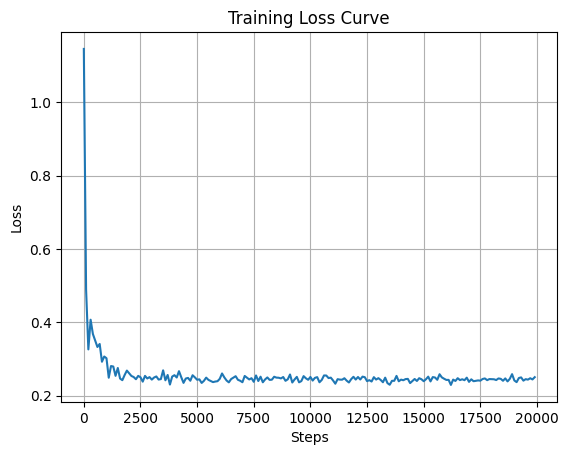

In [334]:
@jax.jit
def step(params, opt_state, key, n_samples=500, T=1.0):
    l, grads = jax.value_and_grad(loss)(params, key, n_samples=n_samples, T=T)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, l

# Initialize parameters
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
params = init_params(subkey)
# Initialize optimizer
lr = 1e-3
optimizer = optax.adam(lr)
opt_state = optimizer.init(params)
n_steps = 20000
losses = []

for i in tqdm(range(n_steps)):
    key, subkey = jax.random.split(key)
    params, opt_state, l= step(params, opt_state, subkey)
    if i % 100 == 0:
        losses.append(l)

best_params = params

# plotting loss curve
plt.plot(jnp.arange(0, n_steps, 100), losses)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

SAMPLING

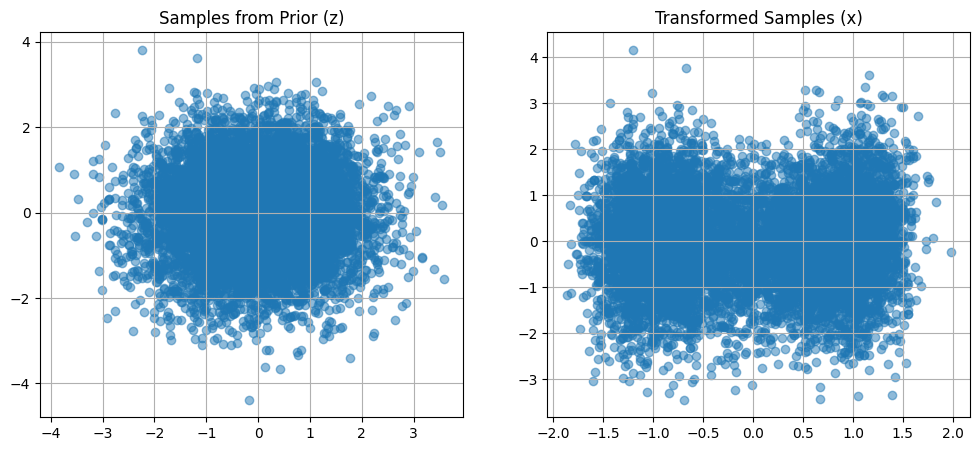

In [335]:
# sampling from prior
key, subkey = jax.random.split(key)
n_samples = 10000
z = jax.random.normal(subkey, (n_samples, 2))
x, log_det = forward(best_params, z)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(z[:, 0], z[:, 1], alpha=0.5)
plt.title("Samples from Prior (z)")
plt.grid(True)
plt.subplot(1,2,2)
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.title("Transformed Samples (x)")
plt.grid(True)
plt.show()

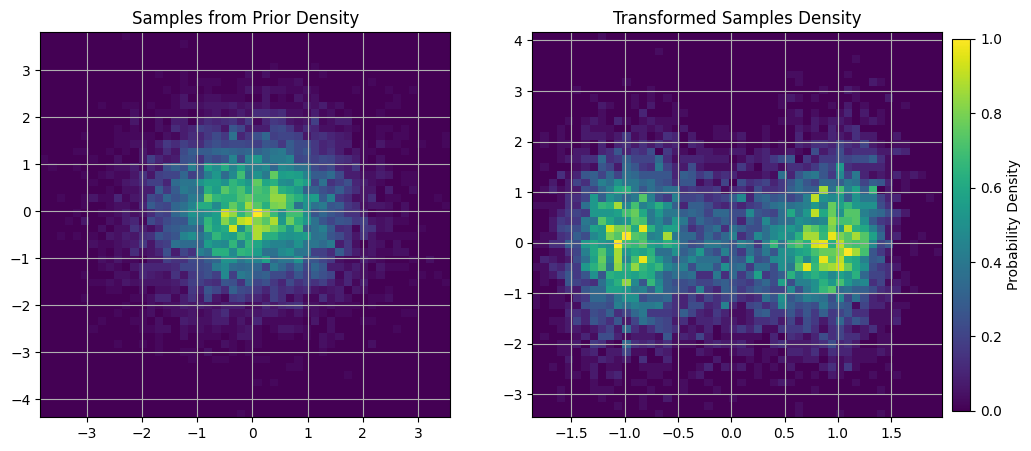

In [336]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.hist2d(z[:, 0], z[:, 1], bins=50, density=True)
plt.title("Samples from Prior Density")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist2d(x[:, 0], x[:, 1], bins=50, density=True)
plt.title("Transformed Samples Density")
plt.grid(True)
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Probability Density')
plt.show()

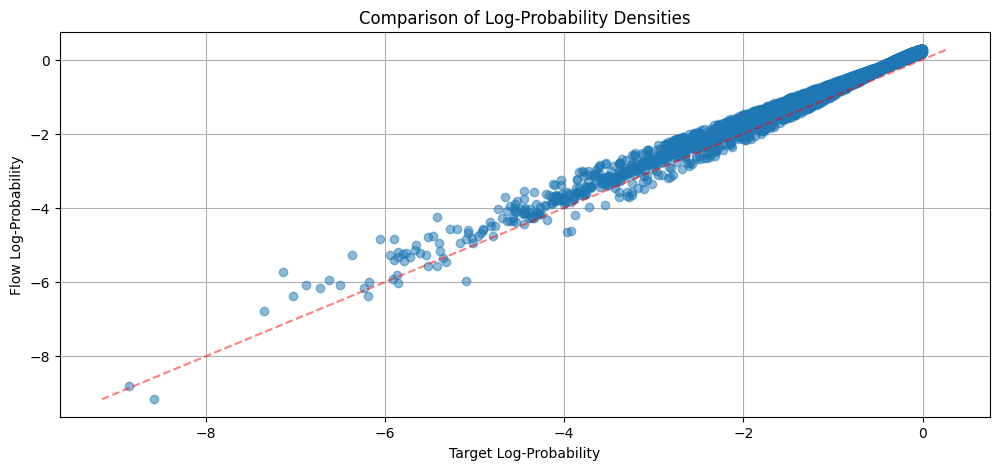

In [337]:
log_p_targ = log_q_target(x, T=1.0)
log_p_flow = log_pz(z) - log_det
plt.figure(figsize=(12, 5))
plt.plot(log_p_targ, log_p_flow, 'o', alpha=0.5)
plt.xlabel("Target Log-Probability")
plt.ylabel("Flow Log-Probability")
plt.title("Comparison of Log-Probability Densities")
# line a 45 degree for reference
min_val = min(jnp.min(log_p_targ), jnp.min(log_p_flow))
max_val = max(jnp.max(log_p_targ), jnp.max(log_p_flow))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
plt.grid(True)
plt.show()
